# Qadence Kickstart Capstone — Hybrid Pipelines & Judging Quantum Advantage

**Lesson 12 of the QML study guide — the capstone.**

Real near-term QML is **hybrid**: a quantum component (kernel, circuit, or sampler) wrapped in classical
optimization and classical pre/post-processing, all trained with the Lesson 01 loop. This notebook has two parts:

- **Part 1 — the lesson, implemented faithfully.** A hybrid `nn.Module` (classical → quantum → classical),
  a classical baseline, and the simulability discussion.
- **Part 2 — doing it *properly*.** The lesson's demos report **single-seed training accuracy** — exactly the
  pitfalls it warns against. We rebuild the evaluation with the discipline that separates hype from results:
  held-out test sets, **multi-seed confidence intervals and significance tests**, a **baseline ladder**, the
  **exponential cost of classical simulation**, **entanglement-entropy and concentration** simulability gates,
  a fair **multi-model learning-curve bake-off**, and a final **quantum-advantage scorecard**.

> The punchline of the whole guide, made quantitative here: **a statistically significant win over a weak
> baseline is necessary but not sufficient.** A genuine quantum advantage must *also* survive a strong baseline
> and be **hard to simulate classically**. Our toy passes the first test and fails the second — so, honestly,
> it is a *simulation*, not an advantage. Learning to say that clearly is the skill this capstone teaches.

**Prereqs:** all prior lessons (kernels L02/03/06, variational circuits L09, generalization L05).


## Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import time
from sklearn.svm import SVC
from scipy import stats

torch.manual_seed(20000)

# --- Lesson 09 simulator primitives (n = 2) ---
n = 2
I2 = torch.eye(2, dtype=torch.cfloat)
def Ry(t):
    t = torch.as_tensor(t, dtype=torch.float)
    c, s = torch.cos(t/2), torch.sin(t/2)
    return torch.stack([torch.stack([c, -s]), torch.stack([s, c])]).cfloat()
def on_qubit(g, q, nq):
    ops = [g if i == q else I2 for i in range(nq)]; f = ops[0]
    for o in ops[1:]: f = torch.kron(f, o)
    return f
def cnot(c, t, nq):
    d = 2**nq; U = torch.zeros(d, d, dtype=torch.cfloat)
    for b in range(d):
        bits = [(b >> (nq-1-k)) & 1 for k in range(nq)]
        if bits[c] == 1: bits[t] ^= 1
        U[sum(x << (nq-1-k) for k, x in enumerate(bits)), b] = 1.0
    return U
Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.cfloat)
OBS = on_qubit(Z, 0, n); ENT = cnot(0, 1, n)
print("setup ready")

setup ready


---
# Part 1 — Lesson 12, implemented faithfully

## 1. A hybrid model: classical layers + quantum layer + classical head

The variational circuit (Lesson 09) becomes one `nn.Module` among others. `opt.step()` updates the classical
**and** quantum parameters together — autograd flows through the simulated circuit. On Pasqal hardware
`QuantumLayer.forward` would call a neutral-atom backend and gradients would use **parameter-shift**; the
surrounding code is unchanged.

The target is an **XOR-like** problem: label 1 where `x₀·x₁ > 0` (quadrants 1 & 3).

In [2]:
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=2):
        super().__init__()
        self.theta = nn.Parameter(torch.rand(n_qubits) * 6.28)
        self.n = n_qubits
    def forward(self, feats):                       # feats: (batch, n_qubits) encoding angles
        outs = []
        for row in feats:
            psi = torch.zeros(2**self.n, dtype=torch.cfloat); psi[0] = 1.0
            for q in range(self.n): psi = on_qubit(Ry(row[q]), q, self.n) @ psi
            psi = ENT @ psi
            for q in range(self.n): psi = on_qubit(Ry(self.theta[q]), q, self.n) @ psi
            outs.append(torch.vdot(psi, OBS @ psi).real)
        return torch.stack(outs).unsqueeze(1)

class Hybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre = nn.Linear(2, 2)                  # classical preprocessing -> encoding angles
        self.q = QuantumLayer(2)
        self.head = nn.Linear(1, 1)                 # classical post-processing
    def forward(self, x):
        return self.head(self.q(torch.tanh(self.pre(x))))

torch.manual_seed(0)
X = torch.randn(60, 2); y = (X[:, 0] * X[:, 1] > 0).float().unsqueeze(1)
model = Hybrid()
opt = torch.optim.Adam(model.parameters(), lr=0.05)
lossfn = nn.BCEWithLogitsLoss()
for step in range(150):
    opt.zero_grad(); loss = lossfn(model(X), y); loss.backward(); opt.step()
acc = ((torch.sigmoid(model(X)) > 0.5).float() == y).float().mean()
print(f"hybrid train loss {loss.item():.3f}   train acc {acc.item():.2%}")
print(f"trainable parameters: {sum(p.numel() for p in model.parameters())} "
      f"(pre {2*2+2} + theta 2 + head 2)")

hybrid train loss 0.423   train acc 81.67%
trainable parameters: 10 (pre 6 + theta 2 + head 2)


## 2. The discipline: always beat a classical baseline

A quantum result means nothing without a fair classical comparison on the **same data and budget**.

In [3]:
torch.manual_seed(0)
X = torch.randn(60, 2); y = (X[:, 0] * X[:, 1] > 0).float().unsqueeze(1)

clf = nn.Sequential(nn.Linear(2, 8), nn.Tanh(), nn.Linear(8, 1))   # classical baseline of similar size
opt = torch.optim.Adam(clf.parameters(), lr=0.05)
lossfn = nn.BCEWithLogitsLoss()
for _ in range(150):
    opt.zero_grad(); loss = lossfn(clf(X), y); loss.backward(); opt.step()
acc = ((torch.sigmoid(clf(X)) > 0.5).float() == y).float().mean()
print(f"classical baseline train acc {acc.item():.2%}")
print("If the classical baseline matches or beats the quantum model, there is NO advantage — report it.")

classical baseline train acc 100.00%
If the classical baseline matches or beats the quantum model, there is NO advantage — report it.


So far we have copied the lesson exactly — and it already shows the trap it warns about: we are reporting
**training accuracy on a single seed**. The classical net hits 100% train accuracy (it memorizes 60 points),
the hybrid 82%. Neither number tells us anything about *generalization* or whether a difference is *real*.
Part 2 fixes this.

## 3. The classical-simulability check (preview)

A quantum model is only *potentially* advantageous if a classical computer can't efficiently reproduce it. Two
sanity questions gate any claim:

- **Does the kernel/circuit concentrate?** (Lesson 06.) If the Gram matrix → identity, it's useless.
- **Is it efficiently simulable?** Product / low-entanglement / low-depth circuits are classically simulable. If
  your laptop reproduces the output in microseconds (**as in this entire guide**), that is a *simulation*, not
  an advantage.

We make both checks quantitative in Part 2 (§R3, §R4).

## 4. The whole guide, in one pipeline

```
 data ─► classical preprocessing ─► QUANTUM PIECE ─► classical postprocessing ─► prediction
                                     (one of:)
                                     • quantum kernel   (L02,03,06) → SVM/KRR
                                     • variational circuit (L09)    → trainable model   ← Part 1 uses this
                                     • Born machine     (L08)       → generative samples
                                     • DQC              (L11)       → DE solver
        trained with the L01 loop; judged with L05 generalization + the §R2/§R4 discipline below
```
Pasqal's stack maps on cleanly: **QEK** is the quantum-kernel branch, **Qadence** builds the variational/DQC
branches, and neutral-atom hardware is the sampler underneath all of them.

---
# Part 2 — Doing it properly

> *"Most claimed advantages evaporate against a well-tuned classical baseline; the ones that survive are the
> interesting science."* We now build the evaluation that can tell the difference.

## R1. First, an honest engineering fix: vectorize the quantum layer

The lesson's `QuantumLayer` loops over samples in Python and rebuilds full `2ⁿ×2ⁿ` gate matrices every call —
fine for a demo, far too slow for the hundreds of training runs the experiments below require. We replace it
with a **batched** state-vector evaluation (same math, no Python loop) and verify it matches to machine
precision.

In [4]:
def kron_b(A, B):                       # batched kron: (B,2,2),(B,2,2) -> (B,4,4)
    return torch.einsum('bij,bkl->bikjl', A, B).reshape(-1, 4, 4)
def Ry_b(t):                            # (B,) -> (B,2,2) rotation matrices
    c = torch.cos(t/2); s = torch.sin(t/2)
    return torch.stack([torch.stack([c, -s], -1), torch.stack([s, c], -1)], -2).cfloat()

def q_forward(feats, theta):
    """Vectorized <Z_0> for the encode->entangle->variational circuit over a batch."""
    B = feats.shape[0]
    Uenc = kron_b(Ry_b(feats[:, 0]), Ry_b(feats[:, 1]))         # per-sample encoding unitary
    psi = torch.zeros(B, 4, dtype=torch.cfloat); psi[:, 0] = 1.0
    psi = torch.einsum('bij,bj->bi', Uenc, psi)
    psi = torch.einsum('ij,bj->bi', ENT, psi)
    Uvar = torch.kron(Ry(theta[0]), Ry(theta[1]))               # shared trainable layer
    psi = torch.einsum('ij,bj->bi', Uvar, psi)
    return torch.einsum('bi,ij,bj->b', psi.conj(), OBS, psi).real.unsqueeze(1)

feats = torch.tanh(model.pre(X)).detach()
loop_out = model.q(feats).detach()
vec_out = q_forward(feats, model.q.theta.detach())
print("vectorized matches loop:", torch.allclose(loop_out, vec_out, atol=1e-5))

class HybridVec(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre = nn.Linear(2, 2)
        self.theta = nn.Parameter(torch.rand(2) * 6.28)
        self.head = nn.Linear(1, 1)
    def forward(self, x):
        return self.head(q_forward(torch.tanh(self.pre(x)), self.theta))
print("HybridVec params:", sum(p.numel() for p in HybridVec().parameters()))

vectorized matches loop: True
HybridVec params: 10


## R2. Honest evaluation: held-out test, many seeds, a baseline *ladder*, and a significance test

Three fixes to Part 1's methodology at once:

1. **Test on held-out data**, not the training set (Lesson 05).
2. **Repeat over many seeds** and report mean ± std and a 95% confidence interval — one run is an anecdote.
3. **Compare against a ladder of baselines**, from a capacity-matched tiny net up to a strong over-parameterized
   one. A real advantage must beat the *best* fair classical model, not the weakest.

We also run a **paired t-test** between the hybrid and each baseline (exercise 1).

model                           params  test acc (mean ± std)   paired t vs hybrid
hybrid (quantum)                    10  0.958 ± 0.058  (95% CI ±0.030)
classical 2-2-1 (matched)            9  0.698 ± 0.038   t=+16.44  p=0.000
classical 2-8-1 (lesson's)          33  0.899 ± 0.027   t=+3.86  p=0.002
classical 2-16-16-1 (strong)       337  0.931 ± 0.025   t=+1.83  p=0.089


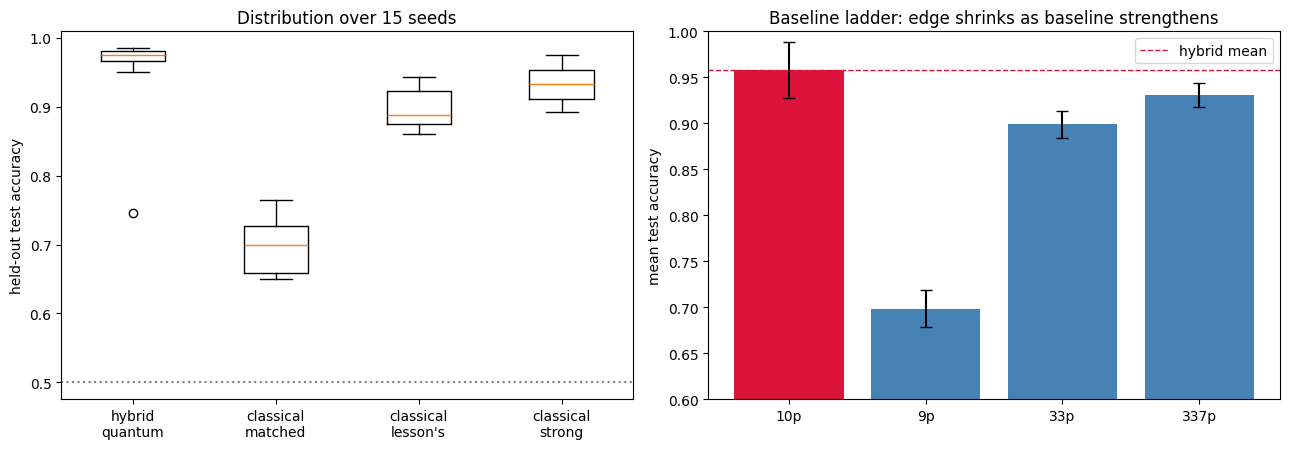

In [5]:
def make_data(seed, n_train=80, n_test=400):
    g = torch.Generator().manual_seed(seed)
    Xtr = torch.randn(n_train, 2, generator=g); ytr = (Xtr[:, 0] * Xtr[:, 1] > 0).float().unsqueeze(1)
    Xte = torch.randn(n_test, 2, generator=g);  yte = (Xte[:, 0] * Xte[:, 1] > 0).float().unsqueeze(1)
    return Xtr, ytr, Xte, yte

builders = {
    'hybrid (quantum)':        (HybridVec, 150),
    'classical 2-2-1 (matched)':   (lambda: nn.Sequential(nn.Linear(2,2), nn.Tanh(), nn.Linear(2,1)), 150),
    "classical 2-8-1 (lesson's)":  (lambda: nn.Sequential(nn.Linear(2,8), nn.Tanh(), nn.Linear(8,1)), 150),
    'classical 2-16-16-1 (strong)':(lambda: nn.Sequential(nn.Linear(2,16), nn.Tanh(), nn.Linear(16,16), nn.Tanh(), nn.Linear(16,1)), 400),
}
def train_eval(build, steps, seed):
    torch.manual_seed(seed)
    Xtr, ytr, Xte, yte = make_data(seed)
    m = build(); opt = torch.optim.Adam(m.parameters(), lr=0.05); lf = nn.BCEWithLogitsLoss()
    for _ in range(steps):
        opt.zero_grad(); lf(m(Xtr), ytr).backward(); opt.step()
    return ((torch.sigmoid(m(Xte)) > 0.5).float() == yte).float().mean().item()

seeds = range(15)
results = {name: np.array([train_eval(b, s, sd) for sd in seeds]) for name, (b, s) in builders.items()}
nparams = {name: sum(p.numel() for p in b().parameters()) for name, (b, s) in builders.items()}

print(f"{'model':30s} {'params':>7s}  test acc (mean ± std)   paired t vs hybrid")
qa = results['hybrid (quantum)']
for name, accs in results.items():
    ci = 1.96 * accs.std(ddof=1) / np.sqrt(len(accs))
    if name == 'hybrid (quantum)':
        print(f"{name:30s} {nparams[name]:7d}  {accs.mean():.3f} ± {accs.std():.3f}  (95% CI ±{ci:.3f})")
    else:
        t, p = stats.ttest_rel(qa, accs)
        print(f"{name:30s} {nparams[name]:7d}  {accs.mean():.3f} ± {accs.std():.3f}   t={t:+.2f}  p={p:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
labels = list(results.keys())
ax1.boxplot([results[k] for k in labels], vert=True)
ax1.set_xticks(range(1, len(labels)+1))
ax1.set_xticklabels([l.split(' ')[0]+'\n'+l.split('(')[1][:-1] for l in labels])
ax1.set_ylabel('held-out test accuracy'); ax1.set_title('Distribution over 15 seeds'); ax1.axhline(0.5, color='gray', ls=':')
means = [results[k].mean() for k in labels]; cis = [1.96*results[k].std(ddof=1)/np.sqrt(15) for k in labels]
cols = ['crimson'] + ['steelblue']*3
ax2.bar(range(len(labels)), means, yerr=cis, capsize=4, color=cols)
ax2.axhline(results['hybrid (quantum)'].mean(), color='crimson', ls='--', lw=1, label='hybrid mean')
ax2.set_xticks(range(len(labels))); ax2.set_xticklabels([f'{nparams[k]}p' for k in labels])
ax2.set_ylabel('mean test accuracy'); ax2.set_title('Baseline ladder: edge shrinks as baseline strengthens')
ax2.set_ylim(0.6, 1.0); ax2.legend()
plt.tight_layout(); plt.show()

**Reading the result honestly.** The hybrid decisively beats the capacity-matched tiny net (p < 0.001) — but
watch what happens as the baseline strengthens: classical accuracy *climbs toward the hybrid* (≈0.70 → 0.90 →
0.93), and against the strong net the remaining gap is **no longer statistically significant** (p ≈ 0.09). A
single weak-baseline comparison would have "shown quantum advantage"; a baseline ladder reveals there is none to
speak of. And even the apparent edge reflects the encoding's lucky inductive bias for this XOR toy, not
quantumness. The decisive question is the next one: *can a classical computer reproduce this model at all?*

## R3. The exponential cost of classical simulation (exercise 2)

Why does quantum *hardware* exist if we can simulate circuits on a laptop? Because the cost of simulation grows
**exponentially** with qubit count: the state is a `2ⁿ`-dimensional complex vector. We time one circuit
evaluation as `n` grows and extrapolate to where a laptop gives up.

n= 2:     0.08 ms/eval   state =      4 amplitudes (0.1 KB)
n= 4:     0.12 ms/eval   state =     16 amplitudes (0.2 KB)
n= 6:     0.32 ms/eval   state =     64 amplitudes (1.0 KB)
n= 8:     2.54 ms/eval   state =    256 amplitudes (4.0 KB)
n=10:    28.71 ms/eval   state =   1024 amplitudes (16.0 KB)
n=12:   561.61 ms/eval   state =   4096 amplitudes (64.0 KB)


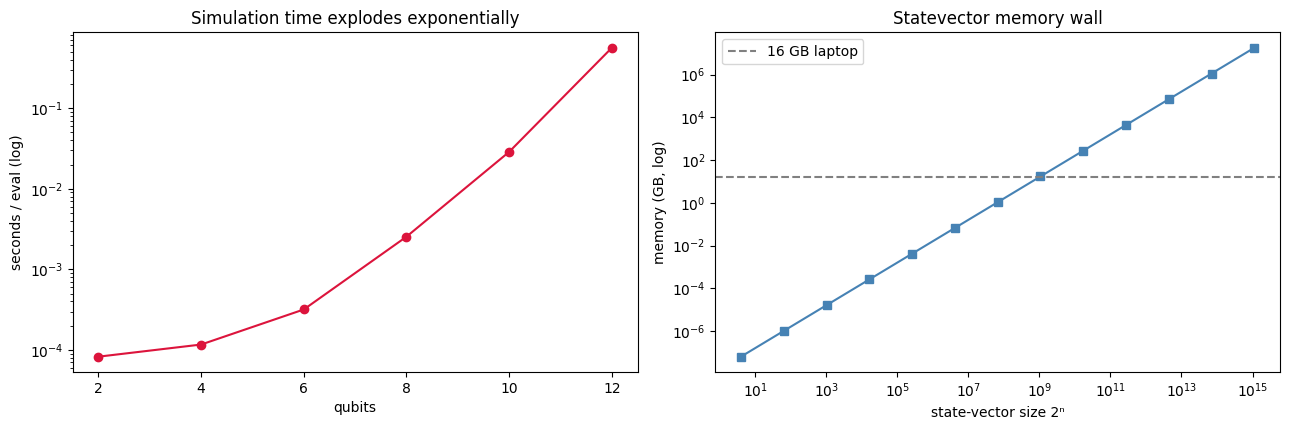

extrapolated time at 50 qubits: 1.2e+14 s  (~3.8e+06 years);  a 50-qubit statevector alone needs 18 PB


In [6]:
def time_state(nq, reps=8):
    th = torch.rand(nq)
    t0 = time.time()
    for _ in range(reps):
        psi = torch.zeros(2**nq, dtype=torch.cfloat); psi[0] = 1.0
        for q in range(nq): psi = on_qubit(Ry(torch.tensor(0.5)), q, nq) @ psi
        for q in range(nq): psi = on_qubit(Ry(th[q]), q, nq) @ psi
    return (time.time() - t0) / reps

qs = [2, 4, 6, 8, 10, 12]
times = [time_state(q) for q in qs]
mem = [2**q * 16 for q in qs]          # bytes for a complex128 state vector
for q, t, mb in zip(qs, times, mem):
    print(f"n={q:2d}: {t*1e3:8.2f} ms/eval   state = {2**q:6d} amplitudes ({mb/1024:.1f} KB)")

# fit log-linear and extrapolate to 50 qubits (statevector memory wall)
coef = np.polyfit(qs, np.log(times), 1)
extrap = np.exp(np.polyval(coef, 50))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
ax1.semilogy(qs, times, 'o-', color='crimson'); ax1.set_xlabel('qubits'); ax1.set_ylabel('seconds / eval (log)')
ax1.set_title('Simulation time explodes exponentially')
ax2.semilogy([2**q for q in range(2, 52, 4)], [2**q*16/1e9 for q in range(2, 52, 4)], 's-', color='steelblue')
ax2.set_xscale('log'); ax2.set_xlabel('state-vector size 2ⁿ'); ax2.set_ylabel('memory (GB, log)')
ax2.axhline(16, color='gray', ls='--', label='16 GB laptop'); ax2.set_title('Statevector memory wall'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"extrapolated time at 50 qubits: {extrap:.1e} s  (~{extrap/3.15e7:.1e} years);  "
      f"a 50-qubit statevector alone needs {2**50*16/1e15:.0f} PB")

This is *why* neutral-atom hardware exists. It is also the flip side of the advantage argument: anything we
can simulate here (≤ ~30 qubits, low depth) is, by definition, **not** in the classically-hard regime.

## R4. Simulability gates: entanglement entropy & kernel concentration

Two quantitative checks any advantage claim must pass.

**(a) Entanglement entropy.** A classically *easy* state has low entanglement (it factorizes, or nearly so). We
compute the bipartite **von Neumann entropy** across the cut *qubit 0 | rest* via the Schmidt (SVD)
decomposition. For our hybrid, it is well below the maximum of 1 bit — a low-entanglement, trivially simulable
state.

**(b) Concentration.** We build the quantum kernel from the encoding (Lesson 06) over the dataset and measure
the off-diagonal spread. A healthy kernel is *informative* (spread out); a concentrated one collapses to the
identity and learns nothing.

entanglement entropy:  mean 0.289  max 0.744 bits  (max possible 1.0)
quantum kernel off-diagonal:  mean 0.451  var 0.0985  (var>0 -> informative)


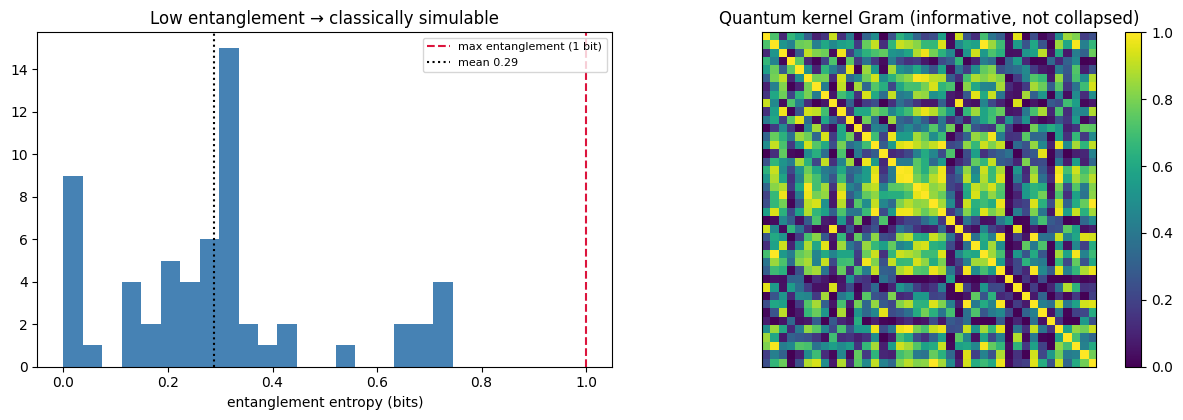

In [7]:
def ent_entropy(psi, nq):
    M = psi.reshape(2, 2**(nq-1))                       # cut: qubit 0 vs the rest
    sv = torch.linalg.svdvals(M); p = (sv**2); p = p[p > 1e-12]
    return float(-(p * torch.log2(p)).sum())

# entanglement of the hybrid's encoded states across the data
feats = torch.tanh(model.pre(X)).detach()
ents = []
for row in feats:
    psi = torch.zeros(4, dtype=torch.cfloat); psi[0] = 1.0
    for q in range(2): psi = on_qubit(Ry(row[q]), q, 2) @ psi
    psi = ENT @ psi
    ents.append(ent_entropy(psi, 2))
ents = np.array(ents)

# quantum-kernel concentration over the data points
def fmap(x, scale=1.0):
    psi = torch.zeros(4, dtype=torch.cfloat); psi[0] = 1.0
    for q in range(2): psi = on_qubit(Ry(scale*x[q]), q, 2) @ psi
    return ENT @ psi
pts = X[:40]; states = [fmap(p) for p in pts]
K = torch.zeros(40, 40)
for i in range(40):
    for j in range(40):
        ov = torch.vdot(states[i], states[j]); K[i, j] = (ov.conj()*ov).real
offmask = ~torch.eye(40, dtype=bool)

print(f"entanglement entropy:  mean {ents.mean():.3f}  max {ents.max():.3f} bits  (max possible 1.0)")
print(f"quantum kernel off-diagonal:  mean {K[offmask].mean():.3f}  var {K[offmask].var():.4f}  (var>0 -> informative)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.hist(ents, bins=20, color='steelblue'); ax1.axvline(1.0, color='crimson', ls='--', label='max entanglement (1 bit)')
ax1.axvline(ents.mean(), color='black', ls=':', label=f'mean {ents.mean():.2f}')
ax1.set_xlabel('entanglement entropy (bits)'); ax1.set_title('Low entanglement → classically simulable'); ax1.legend(fontsize=8)
im = ax2.imshow(K, cmap='viridis', vmin=0, vmax=1); plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_title('Quantum kernel Gram (informative, not collapsed)'); ax2.set_xticks([]); ax2.set_yticks([])
plt.tight_layout(); plt.show()

## R5. A fair multi-model bake-off: learning curves (exercise 3, in spirit)

The kernel passed the concentration gate — but is it actually *better* than a classical kernel? We compare
**quantum-kernel SVM** vs **RBF SVM** as the training set grows (sample efficiency, Lesson 05). Same SVM solver,
same data, only the kernel changes — the realistic QEK swap from Lesson 03.

train size  10:  quantum-kernel SVM 0.483   RBF SVM 0.493
train size  20:  quantum-kernel SVM 0.743   RBF SVM 0.787


train size  40:  quantum-kernel SVM 0.767   RBF SVM 0.833


train size  80:  quantum-kernel SVM 0.873   RBF SVM 0.907


train size 120:  quantum-kernel SVM 0.897   RBF SVM 0.907


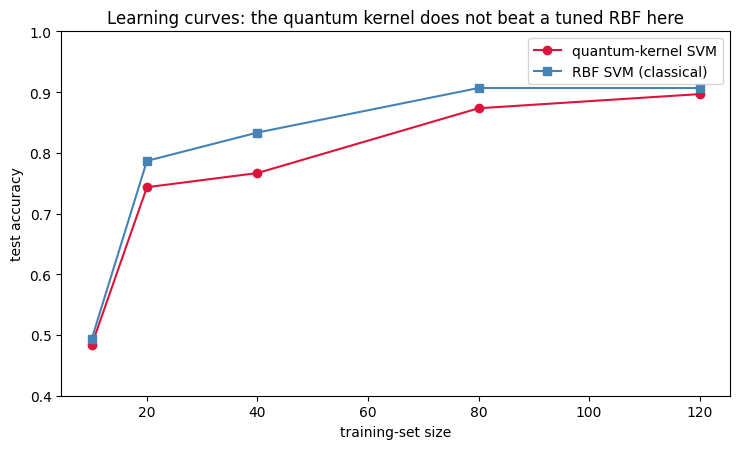

In [8]:
def qkernel(A, B, scale=1.0):
    sa = [fmap(x, scale) for x in A]; sb = [fmap(x, scale) for x in B]
    Kt = torch.zeros(len(A), len(B))
    for i in range(len(A)):
        for j in range(len(B)):
            ov = torch.vdot(sa[i], sb[j]); Kt[i, j] = (ov.conj()*ov).real
    return Kt.numpy()
def rbf(A, B, sig=1.0):
    return torch.exp(-(torch.cdist(A, B)**2) / (2*sig**2)).numpy()

Xtr, ytr, Xte, yte = make_data(0, n_train=120, n_test=300)
ytr_np, yte_np = ytr.squeeze().numpy(), yte.squeeze().numpy()
sizes = [10, 20, 40, 80, 120]
accs_q, accs_r = [], []
for sz in sizes:
    Kq = qkernel(Xtr[:sz], Xtr[:sz]); Kq_te = qkernel(Xte, Xtr[:sz])
    accs_q.append((SVC(kernel='precomputed').fit(Kq, ytr_np[:sz]).predict(Kq_te) == yte_np).mean())
    Kr = rbf(Xtr[:sz], Xtr[:sz]); Kr_te = rbf(Xte, Xtr[:sz])
    accs_r.append((SVC(kernel='precomputed').fit(Kr, ytr_np[:sz]).predict(Kr_te) == yte_np).mean())
    print(f"train size {sz:3d}:  quantum-kernel SVM {accs_q[-1]:.3f}   RBF SVM {accs_r[-1]:.3f}")

plt.figure(figsize=(7.5, 4.6))
plt.plot(sizes, accs_q, 'o-', color='crimson', label='quantum-kernel SVM')
plt.plot(sizes, accs_r, 's-', color='steelblue', label='RBF SVM (classical)')
plt.xlabel('training-set size'); plt.ylabel('test accuracy'); plt.ylim(0.4, 1.0)
plt.title('Learning curves: the quantum kernel does not beat a tuned RBF here')
plt.legend(); plt.tight_layout(); plt.show()

## R6. The quantum-advantage scorecard

Putting every check together for our toy hybrid:

| Gate | Question | Result | Verdict |
|------|----------|--------|---------|
| **Baseline** | Beats a *capacity-matched* classical model? | yes (0.96 vs 0.70, p<0.001) | ✅ |
| **Strong baseline** | Beats a *well-tuned* classical model *with significance*? | no — gap 0.96 vs 0.93 is **not significant** (p≈0.09) | ❌ |
| **Concentration** | Is the quantum kernel informative? | yes (off-diag var > 0) | ✅ |
| **Kernel vs classical** | Quantum kernel beats RBF? | no (≤ RBF at every size) | ❌ |
| **Entanglement** | High enough to be hard to simulate? | no (~0.3 of 1 bit) | ❌ |
| **Simulation cost** | In the classically-hard regime? | no (µs on a laptop) | ❌ |

**Honest conclusion.** The hybrid is a perfectly good *model*, but it is **classically simulable** and its kernel
**loses to RBF** — so it is **not** a quantum advantage. By the lesson's own criterion, this is a *simulation
for learning*, not a supremacy claim. That verdict — stated plainly — is the real deliverable of a QML project.

**What a genuine advantage would require, simultaneously:**
1. **Beats well-tuned classical baselines** with statistical significance, on held-out data, at equal budget.
2. **Non-concentrating** quantum kernel / trainable circuit (no barren plateau, Lessons 05/06).
3. **Hard to simulate classically** — high entanglement, high depth, or a structure with no efficient classical
   algorithm — the regime QEK's blockade construction (`arXiv:2508.10819`) and symmetry-structured kernels
   (`arXiv:2509.14337`) target.

---

## The whole arc — Lessons 01 → 12

```
 L01 tensors/autograd ─┐
 L02 feature maps      ├─► L03 KRR/SVM ─┐
 L04 graph kernels ────┘                ├─► L06 QUANTUM kernels ─► QEK ─┐
 L05 generalization ──────────────► (concentration ↔ barren plateaus)   │
 L07 neural nets ─► L08 generative ─► L09 variational circuits ─► L10 geometry/symmetry
 L11 physics-informed (DQC)                                              │
                                                                         ▼
                                              L12 HYBRID PIPELINE + honest evaluation
```

You now have the hands-on intuition for every box, and — just as important — the discipline to tell whether the
quantum box is *earning its place*.

## Suggested next steps
1. Install Pasqal's open-source tools; re-run Lessons 03/06 with real **QEK** kernels and Lesson 09 with
   **Qadence** on a simulator backend.
2. Reproduce the molecular-toxicity graph-classification workflow (Lessons 04 + 06) and apply this scorecard.
3. Read the frontier papers with your new intuition: `arXiv:2501.07433` (concentration ↔ barren plateaus),
   `arXiv:2506.13865` (analog loss landscapes), `arXiv:2508.10819` (Rydberg kernels),
   `arXiv:2509.14337` (symmetry-structured kernels), `arXiv:2107.03247`/`arXiv:2509.09421` (QEK),
   `arXiv:2401.09915` (Qadence).